In [1]:
import importlib
import peak_gene_utils
importlib.reload(peak_gene_utils)
from peak_gene_utils import *

from utils import *
import squidpy as sq

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata

## Load data

### Annotate cCRE df with three nearest genes

In [2]:
atac = sc.read_h5ad("desc_normalized_atac_peaks.h5ad")
expr = sc.read_h5ad("desc_normalized_rna.h5ad")

In [3]:
niche_pca_anno = sc.read_h5ad("../../h5ad_files/niche_pca_annotated_sp.h5ad")

In [4]:
expr.obs["niche_pca_leiden"] = niche_pca_anno.obs["leiden"].copy()
atac.obs["niche_pca_leiden"] = niche_pca_anno.obs["leiden"].copy()

In [5]:
# get nichePCA pca matrix
X_npca = np.load("../X_npca.npy")
expr.obsm["X_npca"] = X_npca

## Get correlated gene-peak pairs

### get peaks for genes

In [6]:
#### Load gene → peak dicts

import pickle

with open("correlation_dicts/anno_results_by_gene_100k_top20.pkl", "rb") as f:
    anno_results_by_gene = pickle.load(f)

with open("correlation_dicts/no_anno_results_by_gene_100k_top20.pkl", "rb") as f:
    no_anno_results_by_gene = pickle.load(f)

### get genes for peaks

In [7]:
#### Load peak → gene dicts

import json

with open("correlation_dicts/anno_results_by_peak_100k_top1k.json") as f:
#with open("correlation_dicts/anno_results_by_peak_100k.json") as f:
    anno_results_by_peak = json.load(f)

with open("correlation_dicts/no_anno_results_by_peak_100k_top1k.json") as f:
#with open("correlation_dicts/no_anno_results_by_peak_100k.json") as f:
    no_anno_results_by_peak = json.load(f)

In [8]:
import time

In [32]:
num_select_peak = 10000
seed_base = 1
tf = 'tfidf2'
pc = 10
k = 20
similarity = 'cosine'
iter_time = 4
spmethod = 'threshold'
neighbor = 5
sp_dist = 'recip'
pre_select = 'highest'
peaks_num = 50000
distance = 'euclidean'
r = 0.5

start_time = time.time()

#adata = sc.AnnData(adata_raw.X,dtype = 'float32')
idx, sorted_index, simi_matrix, idx_all, scores, selected_peaks_data,similarity_matrix_acb, similarity_matrix_spatial = run_descart(atac, num_select_peak, seed_base=seed_base, tfidf=tf, ifPCA=True, pc=pc, k=k, similarity=similarity, iters=iter_time, spmethod=spmethod,neighbor=neighbor,sp_dist=sp_dist, pre_select=pre_select, peaks_num=peaks_num, distance=distance,r=r)

end_time = time.time()

elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.6f} seconds")

AnnData object with n_obs × n_vars = 5274 × 72148
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'cell_id', 'centroid_x', 'centroid_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_50_genes', 'uniform_density', 'rna_count_based_density', 'niche_pca_leiden'
    var: 'chrom', 'start', 'end', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'is_training'
    uns: 'files', 'gearyC', 'spatial_neighbors', 'label_colors', 'log1p', 'rank_genes_groups'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'
(5274, 72148)
(5274, 5274)
(5274, 10)
0.0
compute scores
scores:
[11553.93189714 11554.35388356 11554.79359615 ... 29201.05939674
 30492.1002968  30500.93314053]
(5274, 5274)
(5274, 10)
0.0
compute scores
scores:
[11867.17420779 11867.30621872 11867.83225987 ... 27712.52467239
 29690.14962537 3

In [33]:
start_time = time.time()
pdist_ = peak_modules_(selected_peaks_data=selected_peaks_data, similarity_matrix=simi_matrix, method='complete')
pdist_ = (pdist_+pdist_.T)/2
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.6f} seconds")
print("Peak modules calculation has been done.")

pdist_.shape

Running time: 5.983418 seconds
Peak modules calculation has been done.


(10000, 10000)

In [34]:
non_diagonal_values = pdist_[np.triu_indices(pdist_.shape[0], k=1)]
peak_similarity = np.copy(pdist_)
thd = np.percentile(non_diagonal_values, 99.5)
peak_similarity[peak_similarity > thd] = thd
peak_distance = thd - peak_similarity
np.fill_diagonal(peak_distance, 0)

/nfs/home/students/l.reich/tangram/src/Descart/utils.py:1081: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = sch.linkage(peak_distance, method=method)


Cluster labels: [6 5 3 ... 5 5 5]


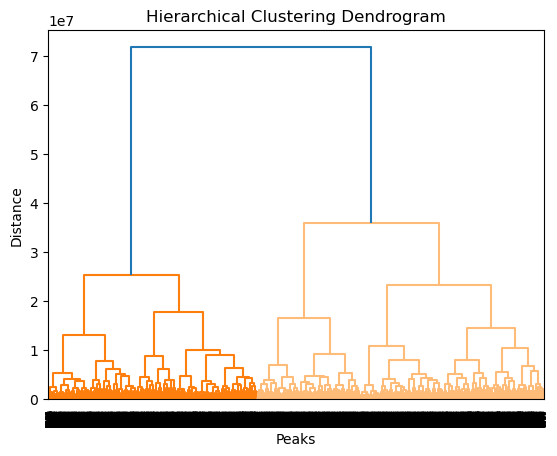

Number 1: Count = 1791, Proportion = 17.91%
Number 2: Count = 785, Proportion = 7.85%
Number 3: Count = 1648, Proportion = 16.48%
Number 4: Count = 2055, Proportion = 20.55%
Number 5: Count = 1707, Proportion = 17.07%
Number 6: Count = 2014, Proportion = 20.14%


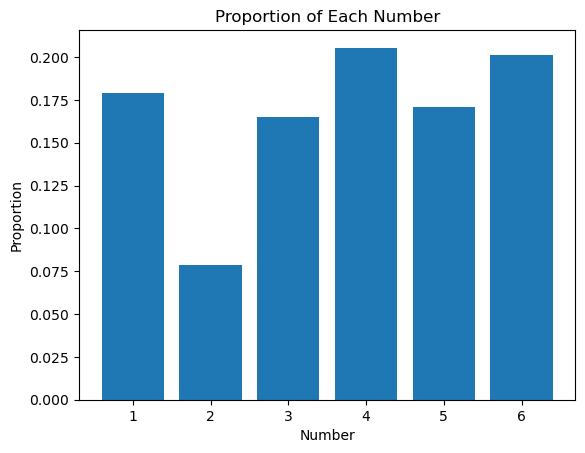

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


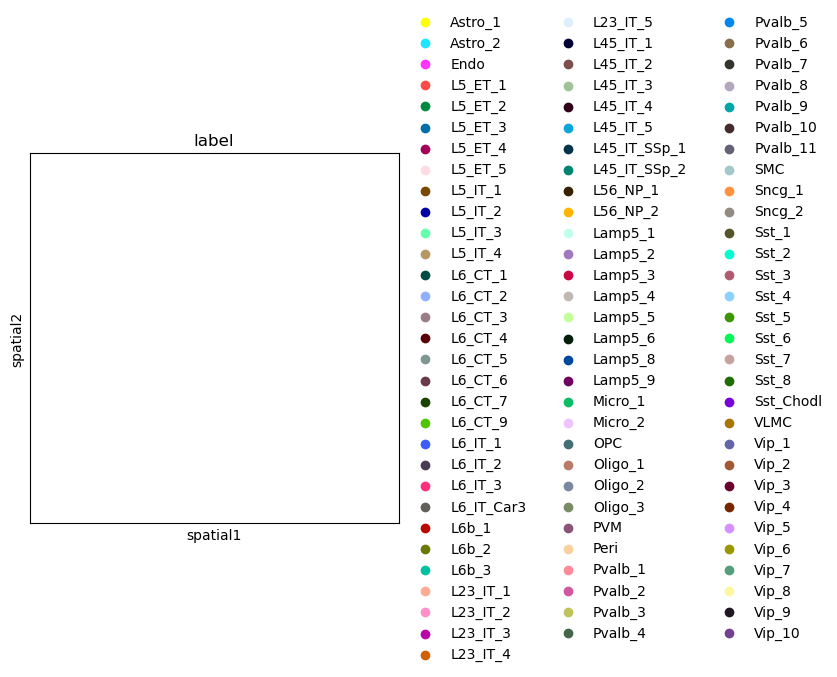

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


Number of peaks in module 1: 1791
Visualize peak module of label 1:
9999


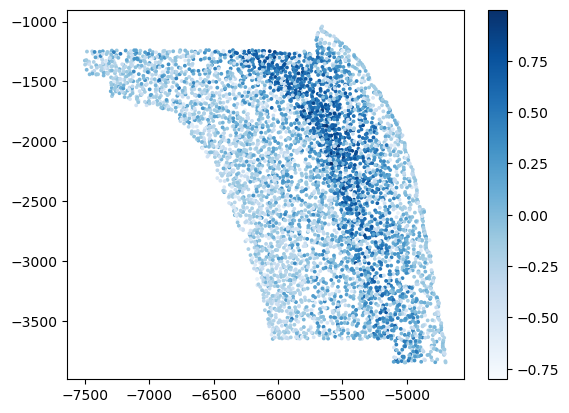

Number of peaks in module 2: 785
Visualize peak module of label 2:
9999


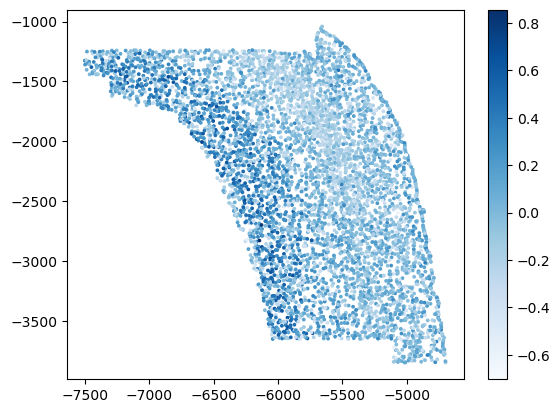

Number of peaks in module 3: 1648
Visualize peak module of label 3:
9999


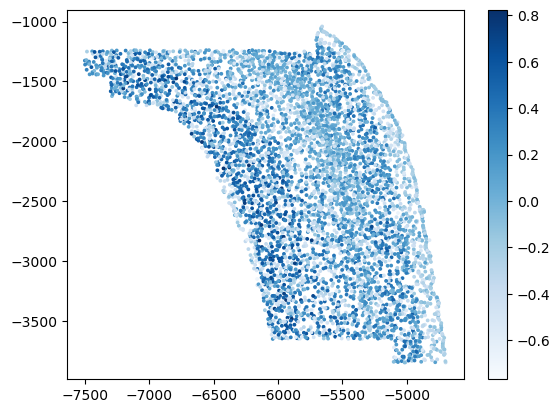

Number of peaks in module 4: 2055
Visualize peak module of label 4:
9999


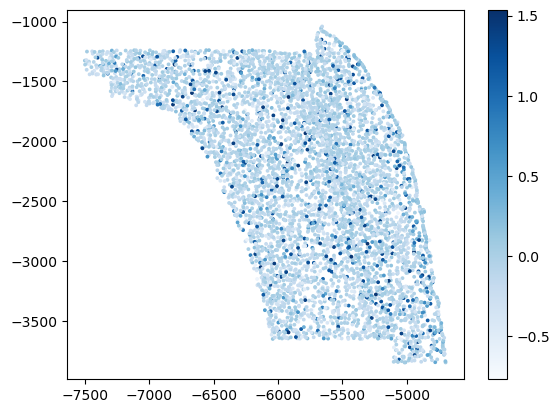

Number of peaks in module 5: 1707
Visualize peak module of label 5:
9999


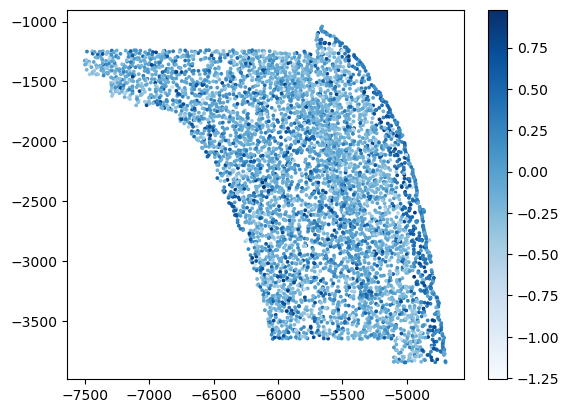

Number of peaks in module 6: 2014
Visualize peak module of label 6:
9999


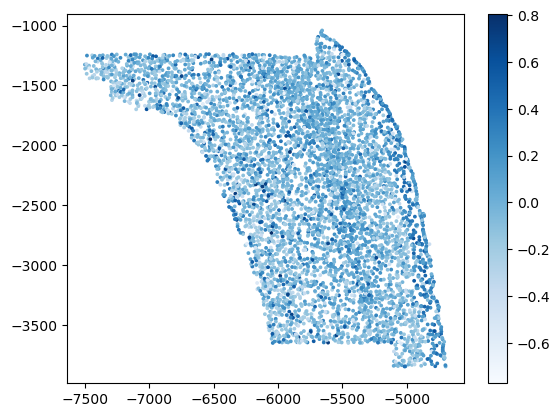

In [35]:
Z,labels = peak_module_cluster(atac,idx,peak_distance,"ward",num_clusters = 6)

In [36]:
def compute_linkage(peak_distance, method='ward'):
    return sch.linkage(peak_distance, method=method)

def get_cluster_labels(Z, num_clusters):
    return sch.fcluster(Z, t=num_clusters, criterion='maxclust')

In [37]:
# Use the existing AnnData with spatially variable peaks
# Ensure the accessibility matrix is log-transformed (if not already)
sc.pp.log1p(atac)

# Run rank_genes_groups on spatial domains
sc.tl.rank_genes_groups(atac, groupby="niche_pca_leiden", method="wilcoxon", use_raw=False)

# Extract the ranked peak names per domain
# This will return a recarray of shape (top_n, n_domains)
ranked_names = atac.uns['rank_genes_groups']['names']

# Convert to DataFrame
domains = ranked_names.dtype.names
ranked_df = pd.DataFrame({domain: ranked_names[domain] for domain in domains})

# Get indices in .var_names
ranked_indices = pd.DataFrame({
    domain: atac.var_names.get_indexer(ranked_df[domain])
    for domain in domains
})

# Output: 
# - ranked_df: DataFrame of top peak names per domain (str)
# - ranked_indices: same shape, but with integer indices
#ranked_df, ranked_indices


/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [45]:
c = ranked_df.head(100)
d = ranked_indices.head(100)

/tmp/ipykernel_1355330/2835165362.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(result.index, rotation=90)
/tmp/ipykernel_1355330/2835165362.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(result.index, rotation=90)
/tmp/ipykernel_1355330/2835165362.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(result.index, rotation=90)
/tmp/ipykernel_1355330/2835165362.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(result.index, rotation=90)
/tmp/ipykernel_1355330/2835165362.py:25: UserWarning: set_ticklabels() should only b

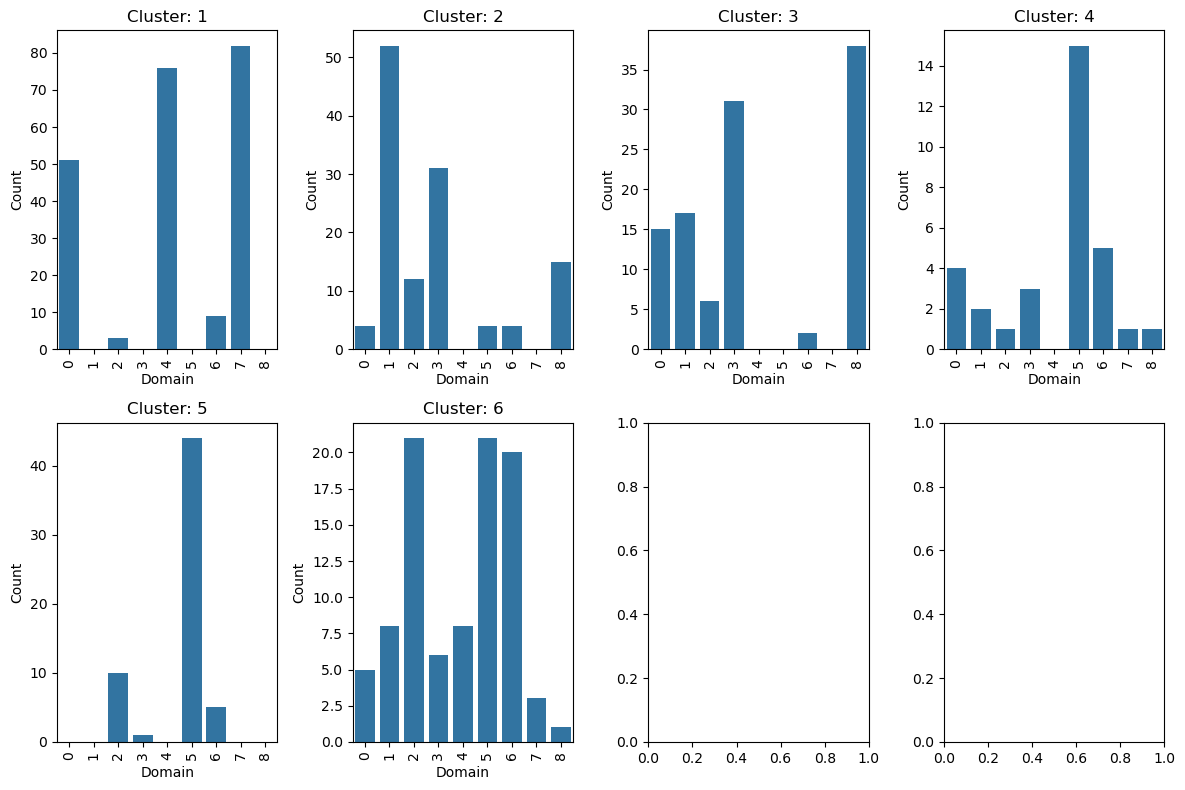

In [46]:
colors = ['#1f77b4', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a', '#d62728', '#ff9896', '#9467bd', '#c5b0d5', '#8c564b', '#c49c94']
sns.set_palette(colors)

result = []
cluster = pd.DataFrame({'idx':idx, 'label':labels})
for i in np.unique(labels):
    data_new = cluster[cluster['label'] == i]
    idx_new = set(list(data_new['idx']))
    result_i = []
    for key in d.keys():
        idx_key = set(list(d[key]))
        result_i.append(len(idx_key.intersection(idx_new)))
    result.append(result_i)
result = pd.DataFrame(np.array(result).T)
result.index = d.keys()
#result.columns = ['1','2','3','4','5','6','7','8', '9']
result.columns = [str(i + 1) for i in range(result.shape[1])]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))

for i, cluster in enumerate(result.columns):
    row, col = divmod(i, 4)
    sns.barplot(x=result.index, y=result[cluster], ax=axes[row, col])
    axes[row, col].set_title(f'Cluster: {cluster}')
    axes[row, col].set_xticklabels(result.index, rotation=90)
    axes[row, col].set_xlabel('Domain')
    axes[row, col].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [40]:
from scipy.cluster.hierarchy import leaves_list

pdist_z = scale(pdist_)
pdist_z = (pdist_z + pdist_z.T) / 2
results_z = pd.DataFrame(pdist_z)

ii = leaves_list(Z)
results_z = results_z.iloc[ii, ii]

label_indexed = pd.DataFrame(results_z, index=range(len(labels)))

# 按照labels的顺序重新排列行
sorted_results_z = label_indexed.loc[np.argsort(labels), np.argsort(labels)]
sorted_results_z

,2563,2578,2580,2582,9847,9792,9802,9808,2650,2586,...,6266,6268,1187,1200,1203,6256,6262,1189,1191,0
2563,3.227829,0.896398,0.468527,0.745471,1.425424,1.213310,1.053759,1.430054,1.258519,2.046085,...,0.031261,-0.256014,-0.928210,-0.414562,-0.339942,-1.299971,-1.377191,0.357920,-1.175520,0.738795
2578,0.896398,3.405677,1.835493,0.646776,1.367324,1.976286,1.822087,1.628334,0.770935,1.484953,...,0.131782,-0.353344,0.258341,0.209765,-0.038687,-0.762109,-0.868631,0.748979,-0.102725,-0.231553
2580,0.468527,1.835493,2.670617,1.689653,0.881009,2.212807,1.918422,2.414863,1.223981,0.858188,...,0.028443,-0.542190,-0.046782,-0.068522,-0.816039,-1.605825,-0.850557,-0.125436,-0.378384,-0.909803
2582,0.745471,0.646776,1.689653,3.366223,0.190211,1.837831,0.440030,1.972010,2.267853,0.521567,...,-0.463073,-0.810248,-0.061479,0.626246,-0.672274,-0.701027,-0.813608,-0.538939,-0.610628,-1.066444
9847,1.425424,1.367324,0.881009,0.190211,4.451059,1.222840,2.209707,1.255932,1.212427,1.687664,...,1.500099,-0.456310,-1.500272,1.367114,0.542720,-1.769563,0.445792,-1.361936,-0.814809,0.549037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6256,-1.299971,-0.762109,-1.605825,-0.701027,-1.769563,-1.676468,-1.457687,-1.795037,-0.747545,-1.274627,...,-0.715289,-0.569555,0.899626,0.239998,0.960872,3.546608,0.567874,0.970907,0.760555,0.406306
6262,-1.377191,-0.868631,-0.850557,-0.813608,0.445792,-1.265036,-0.969487,-1.087807,-0.639920,-0.294044,...,0.756803,0.370643,-1.379860,1.067513,-0.042298,0.567874,4.324820,-1.478403,2.105524,0.464643
1189,0.357920,0.748979,-0.125436,-0.538939,-1.361936,0.471357,-0.300095,0.341725,0.146543,0.438569,...,-0.205644,0.814000,0.330817,-0.345073,1.439053,0.970907,-1.478403,5.735641,-0.225607,0.898493
1191,-1.175520,-0.102725,-0.378384,-0.610628,-0.814809,-1.284120,-0.781968,-0.675940,-1.044718,-0.512217,...,0.565587,0.340346,0.862933,-0.179961,-0.852659,0.760555,2.105524,-0.225607,4.128236,0.409868


In [41]:


name_map = {}
next_mod = 1
for i in sorted_results_z.index:
    mod = labels[i]
    if mod in name_map:
        continue
    if mod == -1:
        continue
    else:
        name_map[int(mod)] = "Module {}".format(next_mod)
        next_mod = next_mod + 1
name_map[-1] = "Module 0"

name_map_r = {v: k for k, v in name_map.items()}
name_map, name_map_r



({1: 'Module 1',
  2: 'Module 2',
  3: 'Module 3',
  4: 'Module 4',
  5: 'Module 5',
  6: 'Module 6',
  -1: 'Module 0'},
 {'Module 1': 1,
  'Module 2': 2,
  'Module 3': 3,
  'Module 4': 4,
  'Module 5': 5,
  'Module 6': 6,
  'Module 0': -1})

In [42]:
colors = sns.color_palette("muted")
colormap = {i: colors[i % 10] if i != -1 else (1.0, 1.0, 1.0) for i in np.unique(labels)}
colormap_r = {v: k for k, v in colormap.items()}
row_colors1 = pd.Series(
    [colormap[i] for i in labels],
    index=range(10000),
)

row_colors = pd.DataFrame({"Module": row_colors1})
row_colors = row_colors.loc[sorted_results_z.index]

cmap = sns.diverging_palette(230, 20, sep=20, s=85, l=50, as_cmap=True)

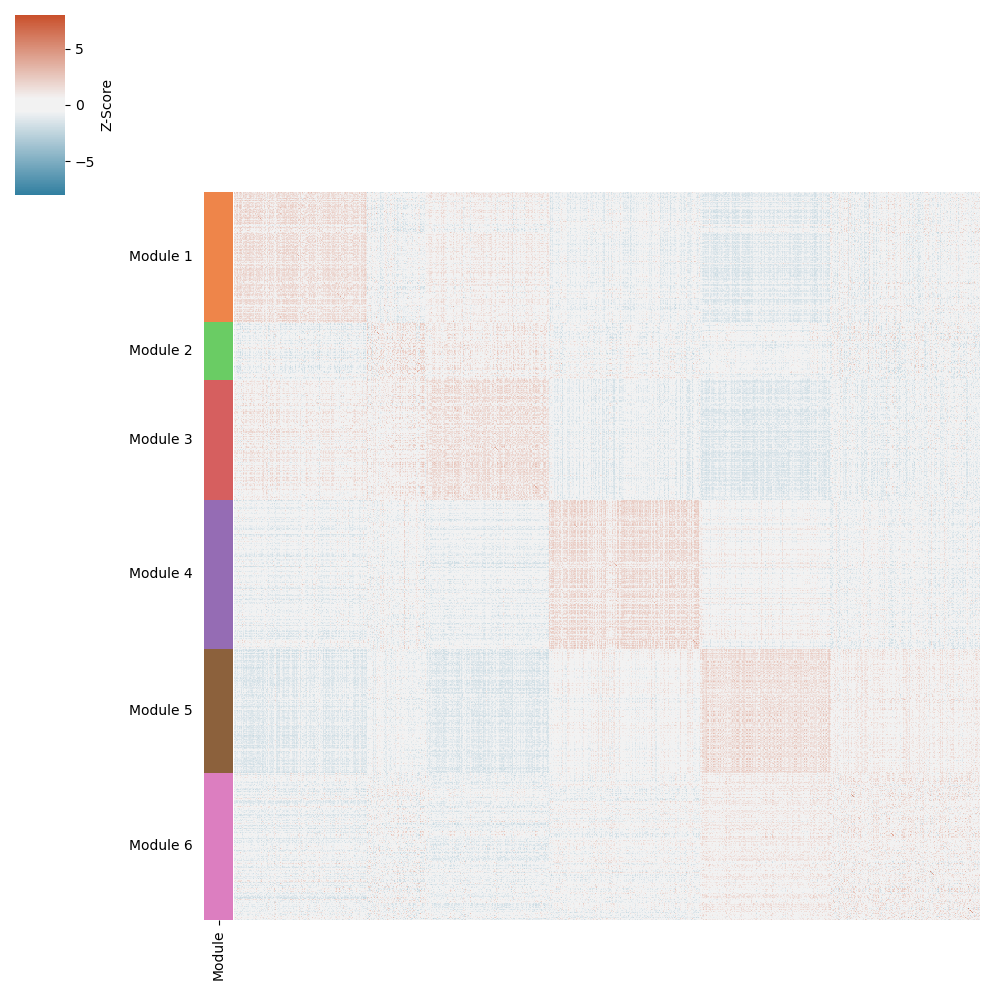

In [44]:
cm = sns.clustermap(
    sorted_results_z,
    row_cluster=False,
    col_cluster=False,
    vmin=-8,
    vmax=8,
    cmap=cmap,
    xticklabels=False,
    yticklabels=False,
    row_colors=row_colors,
    rasterized=True,
    cbar_kws=dict(
        label="Z-Score",
#         ticks=[-8, 0, 8],
    ),
)

fig = plt.gcf()
fig.patch.set_visible(False)
plt.sca(cm.ax_heatmap)
plt.ylabel("")
plt.xlabel("")

# Assuming row_colors is ordered, label the groups
plt.sca(cm.ax_row_colors)
for i in row_colors.Module.unique():
    if i == (1.0, 1.0, 1.0):
        continue
    mid = 0
    count = 0
    cl = colormap_r[i]
    for j, x in enumerate(row_colors.Module.values):
        if x == i:
            mid += j
            count += 1

    mid = mid/count

    plt.text(-.4, mid, name_map[cl],
             horizontalalignment='right',
             verticalalignment='center')

plt.show()

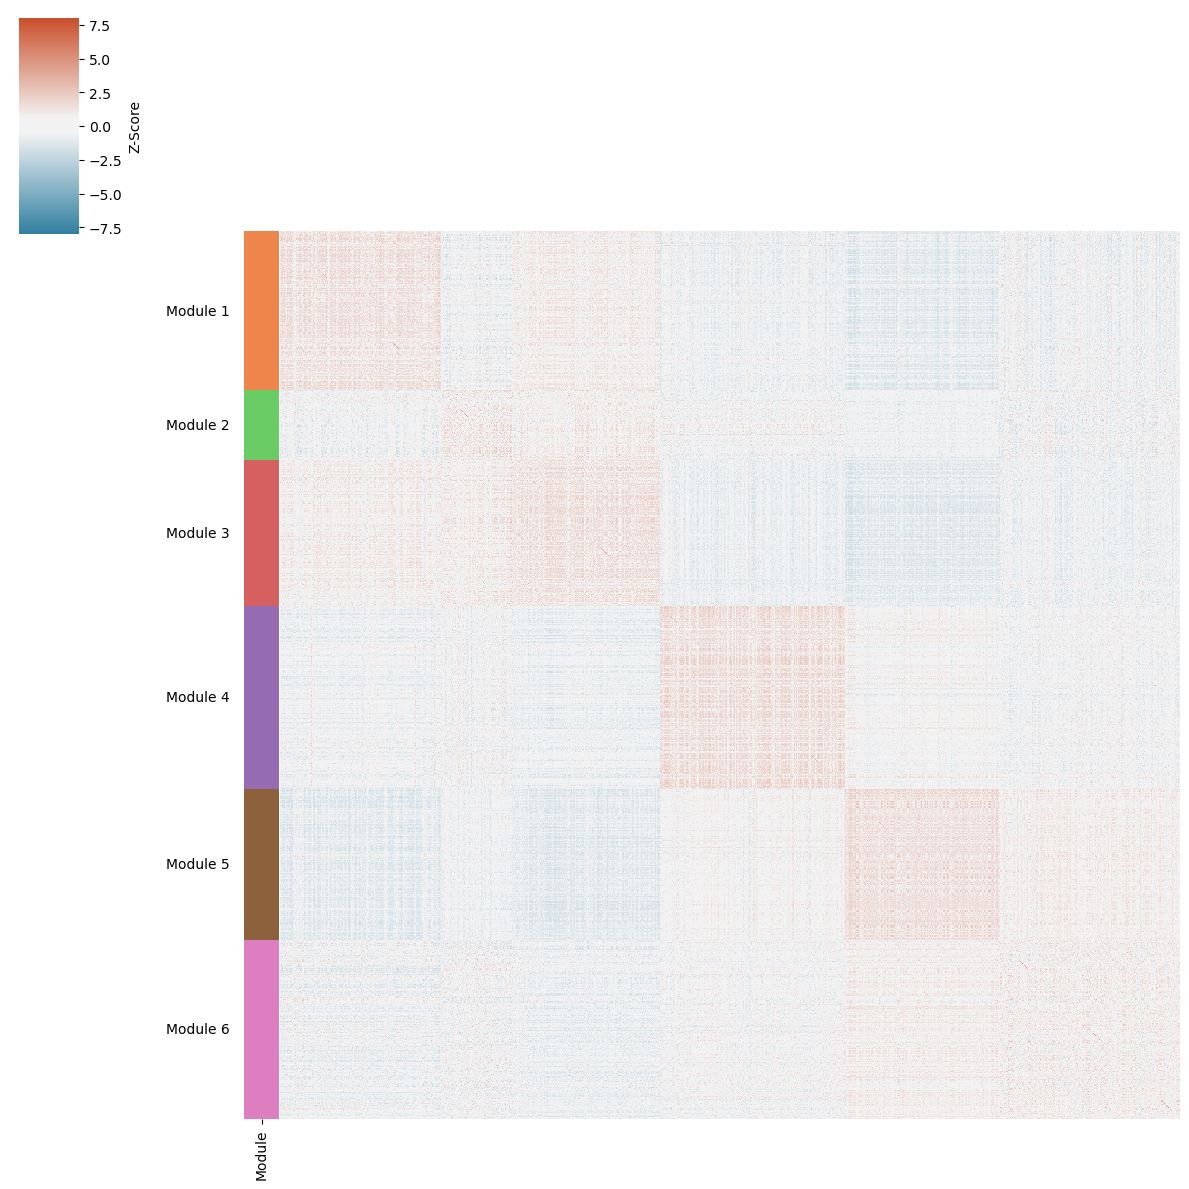

In [48]:
cm = sns.clustermap(
    sorted_results_z,
    row_cluster=False,
    col_cluster=False,
    vmin=-8,
    vmax=8,
    cmap=cmap,
    xticklabels=False,
    yticklabels=False,
    row_colors=row_colors,
    figsize=(12, 12),   # make the heatmap space larger
    rasterized=False,   # keep it sharp
    cbar_kws=dict(
        label="Z-Score",
#         ticks=[-8, 0, 8],
    ),
)

fig = plt.gcf()
fig.patch.set_visible(False)
plt.sca(cm.ax_heatmap)
plt.ylabel("")
plt.xlabel("")

# Assuming row_colors is ordered, label the groups
plt.sca(cm.ax_row_colors)
for i in row_colors.Module.unique():
    if i == (1.0, 1.0, 1.0):
        continue
    mid = 0
    count = 0
    cl = colormap_r[i]
    for j, x in enumerate(row_colors.Module.values):
        if x == i:
            mid += j
            count += 1

    mid = mid/count

    plt.text(-.4, mid, name_map[cl],
             horizontalalignment='right',
             verticalalignment='center')

plt.show()

In [49]:
sv_peaks_df = atac.var.iloc[idx]
sv_peaks_names = sv_peaks_df.index

In [50]:
sv_peaks_names

Index(['chr2:181364565-181365064', 'chr1:37998384-37998883',
       'chr17:56493809-56494308', 'chr9:122650848-122651347',
       'chr16:63091375-63091874', 'chr15:6988182-6988681',
       'chr5:15914788-15915287', 'chr14:105254403-105254902',
       'chr3:80894500-80894999', 'chr8:94678478-94678977',
       ...
       'chr2:37768839-37769338', 'chr8:12486444-12486943',
       'chr11:102604032-102604531', 'chr6:101473235-101473734',
       'chr4:106232457-106232956', 'chr1:165875561-165876060',
       'chr2:102620583-102621082', 'chr5:144881946-144882445',
       'chrx:143482839-143483338', 'chr6:85906858-85907357'],
      dtype='object', length=10000)

In [51]:
anno_p_by_g = set(pd.concat(anno_results_by_gene.values()).index)
no_anno_p_by_g = set(pd.concat(no_anno_results_by_gene.values()).index)

anno_g_by_p = set(anno_results_by_peak.keys())
no_anno_g_by_p = set(set(no_anno_results_by_peak.keys()))

all_peaks = set.union(anno_p_by_g, no_anno_p_by_g, anno_g_by_p, no_anno_g_by_p)

In [52]:
peak_modules = pd.Series(data=labels, index=atac.var_names[idx])  # or part of adata.var['module']

In [53]:
atac_10k = atac[:,idx].copy()

In [54]:
# 100 kb window
window = 100_000

# Prepare peak and gene DataFrames
peaks = atac_10k.var[['chrom', 'start', 'end']].copy()
peaks['peak_id'] = peaks.index
peaks['module'] = peak_modules.loc[peaks.index].values

genes = expr.var[['chrom', 'start', 'end']].copy()
genes['gene_id'] = genes.index

# Make sure coordinates are integers
peaks[['start', 'end']] = peaks[['start', 'end']].astype(int)
# Drop genes with missing coordinates
genes = genes.dropna(subset=['start', 'end'])

# Now safely cast to integers
genes[['start', 'end']] = genes[['start', 'end']].astype(int)
# Initialize output list
links = []

# Iterate chromosome by chromosome (faster, avoids cross-chromosome comparisons)
for chrom in peaks['chrom'].unique():
    peaks_chr = peaks[peaks['chrom'] == chrom]
    genes_chr = genes[genes['chrom'] == chrom]

    # For each peak, find genes within ±100 kb
    for i, peak in peaks_chr.iterrows():
        peak_center = (peak['start'] + peak['end']) // 2
        gene_subset = genes_chr[
            (genes_chr['start'] <= peak_center + window) &
            (genes_chr['end'] >= peak_center - window)
        ]
        for _, gene in gene_subset.iterrows():
            links.append({
                'peak_id': peak['peak_id'],
                'gene_id': gene['gene_id'],
                'module': peak['module'],
                'distance': min(abs(gene['start'] - peak_center), abs(gene['end'] - peak_center))
            })

# Convert to DataFrame
links_df = pd.DataFrame(links)


In [55]:
module_gene_map = links_df.groupby('module')['gene_id'].apply(set).to_dict()

In [56]:
for module_id in range(1, 7):
    module_peaks = peaks[peaks['module'] == module_id]

    bed_df = module_peaks[['chrom', 'start', 'end', 'peak_id']].copy()
    bed_df['score'] = 0
    bed_df['strand'] = '.'

    bed_df.to_csv(
        f'peak_module_{module_id}.bed',
        sep='\t',
        header=False,
        index=False
    )

    print(f"Wrote peak_module_{module_id}.bed with {len(bed_df)} peaks")


Wrote peak_module_1.bed with 1791 peaks
Wrote peak_module_2.bed with 785 peaks
Wrote peak_module_3.bed with 1648 peaks
Wrote peak_module_4.bed with 2055 peaks
Wrote peak_module_5.bed with 1707 peaks
Wrote peak_module_6.bed with 2014 peaks


## Hyperparameter Grid Search     

In [ ]:
import gridsearch
from gridsearch import run_analysis
importlib.reload(gridsearch)

In [ ]:
# Grid search over r and num_clusters
r_vals = [0.2, 0.4, 0.6]
num_cluster_vals = [5, 6, 7]

for r in r_vals:
    for n_clusters in num_cluster_vals:
        try:
            run_analysis(atac, r, n_clusters)
            print(f"✅ Done: r={r}, num_clusters={n_clusters}")
        except Exception as e:
            print(e)
            print(f"❌ Failed: r={r}, num_clusters={n_clusters}")
            print(f"Error: {e}")
